In [ ]:
%pip install -q leafmap pystac-client planetary-computer rioxarray osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 669.2/669.2 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 91.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 133.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 111.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.0/74.0 kB

In [ ]:
import leafmap.foliumap as leafmap   # the map backend that works in Colab
import geopandas, osmnx, rioxarray, planetary_computer, pystac_client
print("All libraries imported OK")

m = leafmap.Map(center=[33.43, -111.94], zoom=14)   # [latitude, longitude]
m.add_basemap("SATELLITE")                          # satellite photo as the background
m

All libraries imported OK


In [ ]:
# ============================================================
# BLOCK 3: Download Sentinel-2 satellite imagery (10 m resolution)
# ============================================================

# DATA SOURCE: Sentinel-2
# - Run by the European Space Agency (ESA) under the EU Copernicus programme.
# - A pair of identical satellites photographs the whole Earth's land roughly every 5 days.
# - Free and open: anyone can download it, no account needed here.
# - Sharpness ("resolution"): each pixel covers 10 m x 10 m on the ground.
#   Good for fields, roads, large buildings and water; too coarse for cars or single rooftops.
# - Level "L2A": already corrected for the atmosphere, so colours are comparable across dates.

# WHERE WE GET IT: Microsoft Planetary Computer
# - A free catalog that hosts Sentinel, Landsat, NAIP and many more datasets.
# - It follows a standard called STAC (SpatioTemporal Asset Catalog): a searchable index
#   where each satellite picture is an "item" and each file inside it is an "asset".

import planetary_computer                     # adds the access token to download links
import rioxarray                              # reads satellite image files into Python
from pystac_client import Client              # searches STAC catalogs
from shapely.geometry import box, shape       # tools for rectangles and shapes

# STUDY AREA: a small rectangle around Tempe, Arizona (about 3 km x 3 km)
# Format: [west longitude, south latitude, east longitude, north latitude]
bbox = [-111.96, 33.41, -111.92, 33.44]

# Connect to the catalog (like opening a search engine for satellite images)
catalog = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

# Search: Sentinel-2 images over our area, Mar-Sep 2026, with under 5% cloud cover
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime="2026-03-01/2026-09-30",
    query={"eo:cloud_cover": {"lt": 5}},
)

# Satellite pictures are big tiles (about 110 km wide). Keep only those that fully cover our area.
items = [i for i in search.items() if shape(i.geometry).contains(box(*bbox))]
print("Scenes found:", len(items))

# Pick the clearest picture (lowest cloud cover)
s2_item = sorted(items, key=lambda i: i.properties["eo:cloud_cover"])[0]
print("Scene:", s2_item.id)
print("Date:", s2_item.datetime.date(), "| Cloud cover %:", s2_item.properties["eo:cloud_cover"])

# DOWNLOAD: "visual" is a ready-made true-colour picture (red, green, blue).
# We cut it to our study area first, so only a small piece is downloaded, not the whole tile.
s2 = rioxarray.open_rasterio(s2_item.assets["visual"].href)
s2 = s2.rio.clip_box(*bbox, crs="EPSG:4326").load()
print("Image size (bands, rows, columns):", s2.shape)

Scenes found: 47
Scene: S2A_MSIL2A_20260324T181811_R084_T12SVC_20260324T230712
Date: 2026-03-24 | Cloud cover %: 0.000975
Image size (bands, rows, columns): (3, 337, 376)


Width on the ground: about 3.8 km
Height on the ground: about 3.4 km


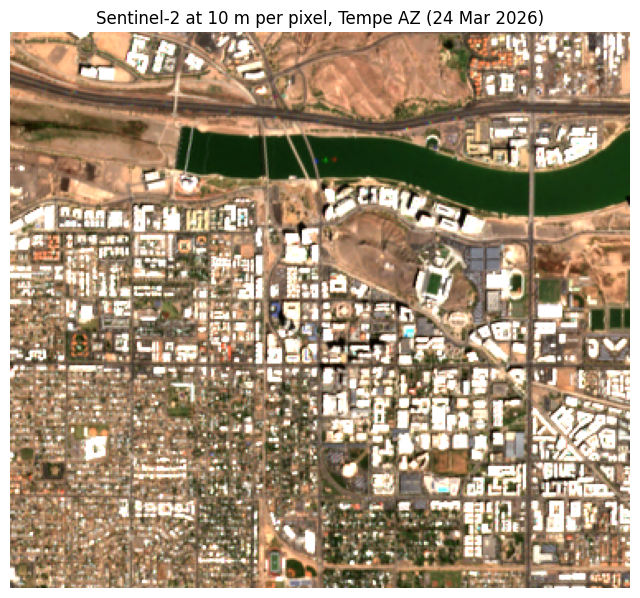

In [ ]:
# ============================================================
# BLOCK 4: Visualise the Sentinel-2 image
# ============================================================
import matplotlib.pyplot as plt     # the standard Python plotting tool

# The image is stored as (bands, rows, columns): red, green and blue layers stacked.
# The plotting tool wants (rows, columns, bands), so we reorder the dimensions.
rgb = s2.transpose("y", "x", "band").values

# How much ground does the picture cover? Each pixel is 10 m wide.
print("Width on the ground: about", round(rgb.shape[1] * 10 / 1000, 1), "km")
print("Height on the ground: about", round(rgb.shape[0] * 10 / 1000, 1), "km")

plt.figure(figsize=(8, 8))
plt.imshow(rgb)
plt.title("Sentinel-2 at 10 m per pixel, Tempe AZ (24 Mar 2026)")
plt.axis("off")
plt.show()

In [ ]:
# ============================================================
# BLOCK 5 - LAYER 1: Buildings (vector polygons) from OpenStreetMap
# ============================================================

# DATA SOURCE: OpenStreetMap (OSM)
# - A free world map built by volunteers, companies and governments, like a Wikipedia for maps.
# - In many US areas, building outlines were added from public footprint datasets
#   (some of them created by AI from aerial imagery).
# - Data type: VECTOR. Each building is one row in a table, with a shape
#   (its outline, stored as a polygon) plus attributes such as type or height.

import osmnx as ox
import leafmap.foliumap as leafmap

bbox = [-111.96, 33.41, -111.92, 33.44]        # [west, south, east, north]
west, south, east, north = bbox

# Ask OSM for everything in our area tagged as a building
buildings = ox.features_from_bbox(bbox=(west, south, east, north), tags={"building": True})

# Keep only polygons (outlines), and a few useful columns
buildings = buildings[buildings.geometry.type.isin(["Polygon", "MultiPolygon"])]
keep = ["geometry"] + [c for c in ["building", "name", "height", "building:levels"] if c in buildings.columns]
buildings = buildings[keep].reset_index(drop=True)

# MEASURE: degrees are not metres, so we switch to a metre-based coordinate system
# (UTM zone 12N, correct for Arizona) to compute each footprint area
buildings["area_m2"] = buildings.to_crs(32612).area.round(0)

print("Number of buildings:", len(buildings))
print("Median footprint (m2):", buildings["area_m2"].median())
print(buildings.head())

# DRAW: orange outlines over a satellite photo
m = leafmap.Map(center=[33.425, -111.94], zoom=15)
m.add_basemap("SATELLITE")
m.add_gdf(buildings, layer_name="Buildings (OSM)",
          style={"color": "orange", "weight": 1, "fillOpacity": 0.3})
m

Number of buildings: 4555
Median footprint (m2): 221.0
                                            geometry     building  \
0  POLYGON ((-111.93725 33.41786, -111.93758 33.4...   university   
1  POLYGON ((-111.936 33.41992, -111.936 33.41994...  residential   
2  POLYGON ((-111.93477 33.4197, -111.93477 33.42...   university   
3  POLYGON ((-111.93283 33.41959, -111.93286 33.4...   university   
4  MULTIPOLYGON (((-111.93127 33.42285, -111.9312...   apartments   

                            name height building:levels  area_m2  
0  H B Farmer Education Building    NaN               3   2457.0  
1                McClintock Hall    NaN               3   1677.0  
2                Social Sciences    NaN             NaN   2683.0  
3           Life Sciences Center    NaN               3   2248.0  
4       San Pablo Residence Hall    NaN               3   2173.0  


Tiles found: 1 | Copernicus_DSM_COG_10_N33_00_W112_00_DEM
Grid size (rows, columns): (109, 145)
Cell size (degrees): 0.00027777777777772254 = about 30 m
Lowest point (m): 342.6614074707031
Highest point (m): 443.87799072265625


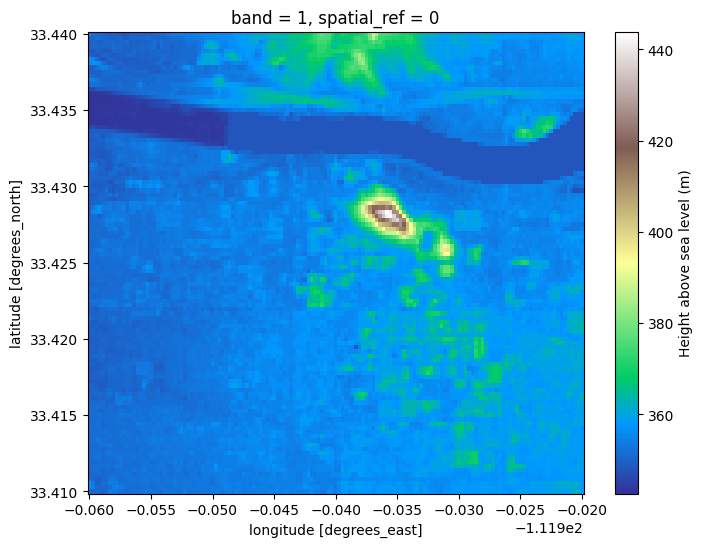

In [ ]:
# ============================================================
# BLOCK 5A: Elevation (raster) from the Copernicus DEM
# ============================================================

# DATA SOURCE: Copernicus DEM GLO-30
# - A worldwide map of ground height ("Digital Elevation Model", DEM), 30 m per pixel.
# - Built from radar measurements by the TanDEM-X satellites, for ESA / the EU.
# - Data type: RASTER. Each pixel holds ONE number: height in metres above sea level.
# - It measures the top surface (roofs, tree tops), not bare ground, so it is called a
#   Digital SURFACE Model. Accuracy is a few metres, which matters in very flat places.
# - Free, served by Microsoft Planetary Computer like our other imagery.

import planetary_computer
import rioxarray
from pystac_client import Client

bbox = [-111.96, 33.41, -111.92, 33.44]        # [west, south, east, north]

catalog = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

# Find the elevation tile that covers our area (tiles are 1 degree x 1 degree)
items = list(catalog.search(collections=["cop-dem-glo-30"], bbox=bbox).items())
print("Tiles found:", len(items), "|", items[0].id)

# Open it, cut it to our area and download that small piece
elev = rioxarray.open_rasterio(items[0].assets["data"].href)
elev = elev.rio.clip_box(*bbox, crs="EPSG:4326").squeeze().load()

# WHAT DID WE GET? A grid with coordinates on each axis and one height per cell
print("Grid size (rows, columns):", elev.shape)
print("Cell size (degrees):", abs(elev.rio.resolution()[0]), "= about 30 m")
print("Lowest point (m):", float(elev.min()))
print("Highest point (m):", float(elev.max()))

# DRAW it. xarray can plot a raster in one line and puts longitude/latitude on the axes.
elev.plot(cmap="terrain", figsize=(8, 6), cbar_kwargs={"label": "Height above sea level (m)"})

count    4555.0
mean      355.2
std         3.6
min       348.7
25%       352.6
50%       354.7
75%       357.2
max       409.3
Name: elev_m, dtype: float64
       building      elev_m
168  industrial  409.299988
169  industrial  401.899994
52          yes  378.200012


Text(0.5, 1.0, 'Buildings coloured by elevation (m)')

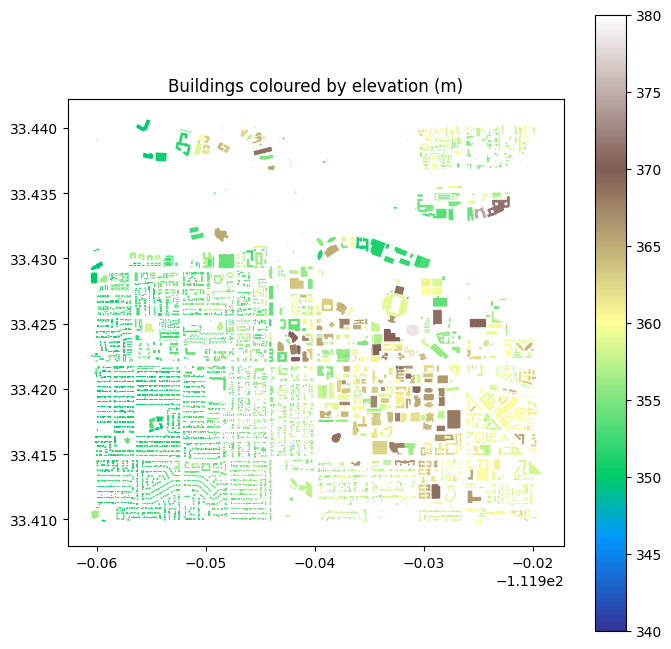

In [ ]:
# BLOCK 5B: Merge raster -> vector ("point sampling")
# Idea: read the raster cell under each building's centre and store it as a new column.
import xarray as xr

# Building centres (computed in a metre-based CRS so "centre" is accurate), back to lon/lat
centres = buildings.to_crs(32612).centroid.to_crs(4326)

# Pick the nearest elevation cell for every centre point at once
xs = xr.DataArray(centres.x.values, dims="pt")
ys = xr.DataArray(centres.y.values, dims="pt")
buildings["elev_m"] = elev.sel(x=xs, y=ys, method="nearest").values.round(1)

print(buildings["elev_m"].describe().round(1))
print(buildings.nlargest(3, "elev_m")[["building", "elev_m"]])   # highest-sited buildings

# Draw buildings coloured by the height value they just received
ax = buildings.plot(column="elev_m", cmap="terrain", vmin=340, vmax=380,
                    legend=True, figsize=(8, 8))
ax.set_title("Buildings coloured by elevation (m)")

In [ ]:
# ============================================================
# BLOCK 6: Solar panels (vector) from OpenStreetMap
# ============================================================

# DATA SOURCE: OpenStreetMap (OSM), same source as the buildings.
# - OSM features carry "tags": key=value labels that say what something is.
# - Solar installations are tagged  generator:source=solar  (rooftop and ground arrays)
#   or  plant:source=solar  (large solar farms).
# - Volunteers usually trace them from aerial photos, so COVERAGE IS UNEVEN:
#   no solar in OSM does not mean no solar on the ground.
# - Data type: VECTOR again. Some are polygons (outlines of an array),
#   some are points (a single marked location).

import osmnx as ox
import leafmap.foliumap as leafmap

# Same study area as Block 5
bbox = [-111.96, 33.41, -111.92, 33.44]        # [west, south, east, north]
west, south, east, north = bbox

# A list of tags means "match ANY of these", so this catches both kinds of solar
solar_tags = {"generator:source": "solar", "plant:source": "solar"}

try:
    solar = ox.features_from_bbox(bbox=(west, south, east, north), tags=solar_tags)
    solar = solar.reset_index(drop=True)
    print("Solar features found:", len(solar))
    print(solar.geometry.type.value_counts())          # how many polygons vs points

    # Area of each polygon in square metres (UTM zone 12N is metre-based, correct for Arizona)
    polys = solar[solar.geometry.type.isin(["Polygon", "MultiPolygon"])].copy()
    polys["area_m2"] = polys.to_crs(32612).area.round(0)
    print("Total mapped panel area (m2):", polys["area_m2"].sum())

except Exception as e:
    # osmnx raises an error when nothing matches
    solar = None
    print("No solar features found in OSM for this area:", e)

# DRAW: buildings in faint orange for context, solar on top in bright red
m = leafmap.Map(center=[33.425, -111.94], zoom=15)
m.add_basemap("SATELLITE")
m.add_gdf(buildings, layer_name="Buildings (OSM)",
          style={"color": "orange", "weight": 1, "fillOpacity": 0.1})
if solar is not None:
    m.add_gdf(solar, layer_name="Solar (OSM)",
              style={"color": "red", "weight": 2, "fillColor": "red", "fillOpacity": 0.6})
m

Solar features found: 228
Polygon         225
MultiPolygon      2
Point             1
Name: count, dtype: int64
Total mapped panel area (m2): 295065.0


Found: ESA_WorldCover_10m_2021_v200_N33W114
Found: ESA_WorldCover_10m_2020_v100_N33W114
Using: ESA_WorldCover_10m_2021_v200_N33W114
Size (rows, columns): (361, 481)


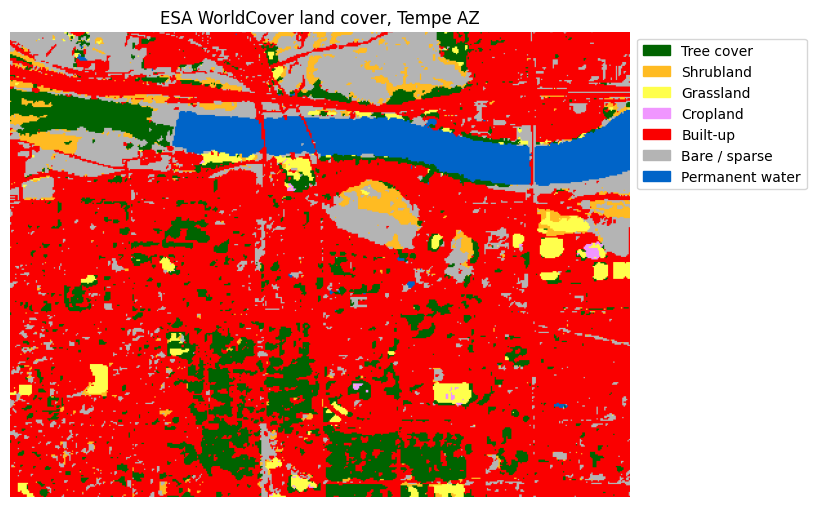

          class  percent
       Built-up     62.5
  Bare / sparse     12.9
     Tree cover     12.6
Permanent water      6.2
      Shrubland      3.4
      Grassland      2.3
       Cropland      0.1


In [ ]:
# ============================================================
# BLOCK 7: Land use / land cover (raster) from ESA WorldCover
# ============================================================

# DATA SOURCE: ESA WorldCover
# - A global land-cover map at 10 m resolution, made by the European Space Agency
#   by running a machine-learning classifier on Sentinel-1 and Sentinel-2 images.
# - Data type: RASTER. A grid of pixels where each pixel holds a class CODE
#   (10 = trees, 50 = built-up, ...). The numbers are labels, not measurements.
# - Overall accuracy is roughly three-quarters, so it is a useful guide, not ground truth.
#   Expect mistakes, especially in cities where trees, roofs and roads mix inside one pixel.
# - Served by Microsoft Planetary Computer, the same catalog as Sentinel-2.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import planetary_computer
import rioxarray
from pystac_client import Client

bbox = [-111.96, 33.41, -111.92, 33.44]        # [west, south, east, north]

catalog = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

# Find the WorldCover tiles over our area (there can be more than one year)
items = list(catalog.search(collections=["esa-worldcover"], bbox=bbox).items())
for i in items:
    print("Found:", i.id)
item = sorted(items, key=lambda i: i.id)[-1]        # the ids contain the year, so this picks the newest
print("Using:", item.id)

# Open the map, cut it to our area and download that small piece
lc = rioxarray.open_rasterio(item.assets["map"].href)
lc = lc.rio.clip_box(*bbox, crs="EPSG:4326").squeeze().load()
print("Size (rows, columns):", lc.shape)

# WHAT THE NUMBERS MEAN (code: name, colour)
worldcover = {
    10:  ("Tree cover",          "#006400"),
    20:  ("Shrubland",           "#ffbb22"),
    30:  ("Grassland",           "#ffff4c"),
    40:  ("Cropland",            "#f096ff"),
    50:  ("Built-up",            "#fa0000"),
    60:  ("Bare / sparse",       "#b4b4b4"),
    70:  ("Snow and ice",        "#f0f0f0"),
    80:  ("Permanent water",     "#0064c8"),
    90:  ("Herbaceous wetland",  "#0096a0"),
    95:  ("Mangroves",           "#00cf75"),
    100: ("Moss and lichen",     "#fae6a0"),
}

# A lookup table: position = class code, value = RGB colour. Indexing it with the map
# paints every pixel in one step.
lut = np.full((256, 3), 255, dtype=np.uint8)
for code, (name, colour) in worldcover.items():
    lut[code] = (np.array(mcolors.to_rgb(colour)) * 255).astype(np.uint8)

# DRAW the map with a legend of the classes that actually appear
present = np.unique(lc.values)
legend = [mpatches.Patch(color=worldcover[c][1], label=worldcover[c][0])
          for c in present if c in worldcover]
plt.figure(figsize=(8, 8))
plt.imshow(lut[lc.values.astype(np.uint8)])
plt.legend(handles=legend, loc="upper left", bbox_to_anchor=(1, 1))
plt.title("ESA WorldCover land cover, Tempe AZ")
plt.axis("off")
plt.show()

# HOW MUCH OF EACH CLASS? (share of pixels, which here are nearly equal in area)
codes, counts = np.unique(lc.values, return_counts=True)
table = pd.DataFrame({"code": codes, "pixels": counts})
table["class"] = table["code"].map(lambda c: worldcover.get(c, (f"Other ({c})", ""))[0])
table["percent"] = (100 * table["pixels"] / table["pixels"].sum()).round(1)
print(table[["class", "percent"]].sort_values("percent", ascending=False).to_string(index=False))